качаем библиотеки

In [3]:
import pandas as pd
import numpy as np

import statistics
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import t

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [5]:
### для загрузки данных
with open(r'project.txt', 'r') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [9]:
product1_sales = np.array(product1)
product2_sales = np.array(product2)

product1_sales_mean = product1_sales.mean()
product1_sales_median = np.median(product1_sales)
product1_sales_mode = statistics.mode(product1_sales)

product2_sales_mean = product2_sales.mean()
product2_sales_median = np.median(product2_sales)
product2_sales_mode = statistics.mode(product2_sales)

products_data_center = pd.DataFrame(
    {'Product1': [product1_sales_mean, product1_sales_median, product1_sales_mode],
     'Product2': [product2_sales_mean, product2_sales_median, product2_sales_mode]},
    index = ['mean', 'median', 'mode']
)
products_data_center

,Product1,Product2
mean,199.103,193.5
median,198.500,194.5
mode,186.000,227.0


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

In [12]:
print('''
Мода будет наименее показательной, так как она даже не показывает центральную тендецию этих данных, а просто какое значение выходит чаще.
Например, если у нас было бы каждое значение уникальным и самое маленькое повторилось дважды, это бы ничего бы не сказало о том какое значение
было бы репрезентативным этой выборки.
На основе среднего значения и медианы, видно что старый продукт 1 приносит больше выручки.
''')


Мода будет наименее показательной, так как она даже не показывает центральную тендецию этих данных, а просто какое значение выходит чаще.
Например, если у нас было бы каждое значение уникальным и самое маленькое повторилось дважды, это бы ничего бы не сказало о том какое значение
было бы репрезентативным этой выборки.
На основе среднего значения и медианы, видно что старый продукт 1 приносит больше выручки.



**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [15]:
product1_sales_std = product1_sales.std(ddof = 1)
product2_sales_std = product2_sales.std(ddof = 1)

products_data_center.loc['st. deviation'] = [product1_sales_std, product2_sales_std]
products_data_center

,Product1,Product2
mean,199.103000,193.500000
median,198.500000,194.500000
mode,186.000000,227.000000
st. deviation,28.808372,29.738082


In [17]:
print('''
Как видно по стандартным отклонениям выручек обоих продуктов, у старого продукта продукта 1 стандартное отклонение меньше, что свидетельствует
о меньшем разбросе данных, что говорит о том что показатели центральной тендеции являются более репрезентативными (более точными) по сравнению
с показателями нового продукта продукта 2.
''')


Как видно по стандартным отклонениям выручек обоих продуктов, у старого продукта продукта 1 стандартное отклонение меньше, что свидетельствует
о меньшем разбросе данных, что говорит о том что показатели центральной тендеции являются более репрезентативными (более точными) по сравнению
с показателями нового продукта продукта 2.



**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

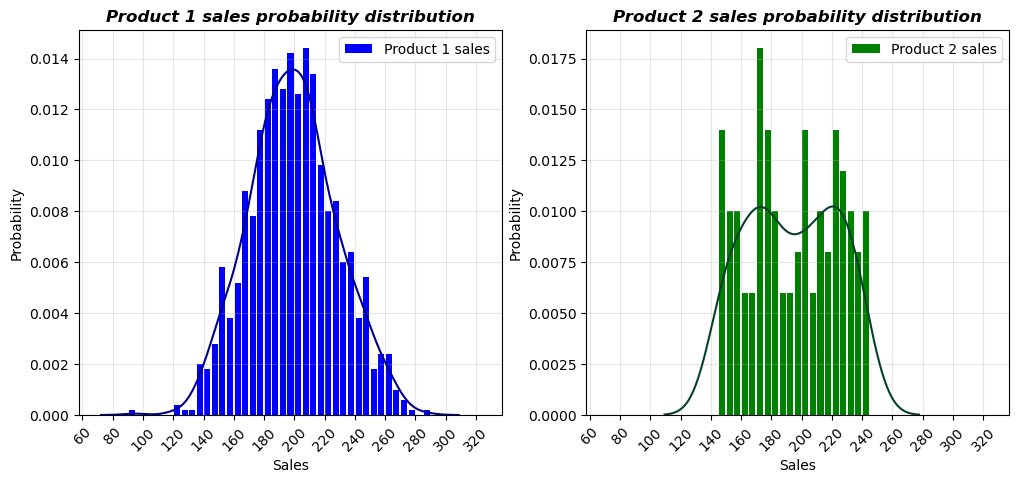

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

sns.kdeplot(product1_sales, ax = ax[0], color = '#00008B')
sns.kdeplot(product2_sales, ax = ax[1], color = '#06402B')

ax[0].hist(product1_sales, bins = range(70, 330, 5), rwidth = 0.8, color = 'blue', label = 'Product 1 sales', density = True)
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel('Sales')
ax[0].set_ylabel('Probability')
ax[0].set_title('Product 1 sales probability distribution', fontweight = 'bold', fontsize = 12, fontstyle = 'italic')
ax[0].set_xticks(range(60, 340, 20))
ax[0].tick_params(axis = 'x', labelrotation = 45)
ax[0].legend(fontsize = 10, loc = 'upper right')

ax[1].hist(product2_sales, bins = range(70, 330, 5), rwidth = 0.8, color = 'green', label = 'Product 2 sales', density = True)
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Probability')
ax[1].set_title('Product 2 sales probability distribution', fontweight = 'bold', fontsize = 12, fontstyle = 'italic')
ax[1].set_xticks(range(60, 340, 20))
ax[1].tick_params(axis = 'x', labelrotation = 45)
ax[1].legend(fontsize = 10, loc = 'upper right')

plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [22]:
product1_sales_range = product1_sales.max() - product1_sales.min()
product2_sales_range = product2_sales.max() - product2_sales.min()

print(f"Размах выручки у Product 1: {product1_sales_range:.2f}")
print(f"Размах выручки у Product 2: {product2_sales_range:.2f}")

Размах выручки у Product 1: 193.00
Размах выручки у Product 2: 97.00


In [24]:
print('''
Размах выручки у продукта 2 намного меньше чем у продукта 1, хотя стандартное отклонение у продукта 1 меньше. Это просто говорит о том что у продукта 1
есть несколько значений выручки, которые намного больше/меньше наибольшего/наименьшего значения выручки продукта 2 и все. Разброс данных у продукта 1 все
равно меньше так как большая часть данных сконцентрированна ближе к среднему значению, в то время как у продукта 2 данные в среднем имеют дистанцию
от среднего значения больше, несмотря на небольшой размах.
''')


Размах выручки у продукта 2 намного меньше чем у продукта 1, хотя стандартное отклонение у продукта 1 меньше. Это просто говорит о том что у продукта 1
есть несколько значений выручки, которые намного больше/меньше наибольшего/наименьшего значения выручки продукта 2 и все. Разброс данных у продукта 1 все
равно меньше так как большая часть данных сконцентрированна ближе к среднему значению, в то время как у продукта 2 данные в среднем имеют дистанцию
от среднего значения больше, несмотря на небольшой размах.



**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [28]:
product1_sales_IQR = np.percentile(product1_sales, 75) - np.percentile(product1_sales, 25)
product2_sales_IQR = np.percentile(product2_sales, 75) - np.percentile(product2_sales, 25)

print(f"Межквартильный размах выручки у Product 1: {product1_sales_IQR:.2f}")
print(f"Межквартильный размах выручки у Product 2: {product2_sales_IQR:.2f}")

Межквартильный размах выручки у Product 1: 38.25
Межквартильный размах выручки у Product 2: 51.00


In [30]:
print('''
Как и ожидалось, межквартильный размах у продукта 1 меньше чем у продукта 2, несмотря на меньший размах выручки.
''')


Как и ожидалось, межквартильный размах у продукта 1 меньше чем у продукта 2, несмотря на меньший размах выручки.



In [32]:
p1_ll = np.percentile(product1_sales, 25) - 1.5 * product1_sales_IQR
p1_hl = np.percentile(product1_sales, 75) + 1.5 * product1_sales_IQR

p2_ll = np.percentile(product2_sales, 25) - 1.5 * product2_sales_IQR
p2_hl = np.percentile(product2_sales, 75) + 1.5 * product2_sales_IQR

product1_sales_no_outliers = product1_sales[ (product1_sales <= p1_hl) & (product1_sales >= p1_ll) ]
product2_sales_no_outliers = product2_sales[ (product2_sales <= p2_hl) & (product2_sales >= p2_ll) ]

p1_no_out_range = product1_sales_no_outliers.max() - product1_sales_no_outliers.min()
p1_no_out_IQR = np.percentile(product1_sales_no_outliers, 75) - np.percentile(product1_sales_no_outliers, 25)
p1_no_out_std = product1_sales_no_outliers.std(ddof = 1)

p2_no_out_range = product2_sales_no_outliers.max() - product2_sales_no_outliers.min()
p2_no_out_IQR = np.percentile(product2_sales_no_outliers, 75) - np.percentile(product2_sales_no_outliers, 25)
p2_no_out_std = product2_sales_no_outliers.std(ddof = 1)

products_no_outliers_spread = pd.DataFrame({
    'Product 1': [p1_no_out_range, p1_no_out_IQR, p1_no_out_std],
    'Product 2': [p2_no_out_range, p2_no_out_IQR, p2_no_out_std]
}, index = ['range', 'IQR', 'st. deviation'])

products_no_outliers_spread

,Product 1,Product 2
range,151.000000,97.000000
IQR,37.250000,51.000000
st. deviation,28.314082,29.738082


In [34]:
print('''
Убрав выбросы с данных о выручке, разброс данных для обоих продуктов не сильно изменился. У продукта 2 не было выбросов, в то время как после удаления
выбросов у продукта 1, изменился только размах на 42 значения. В остальном, почти такие же значения разброса данных: как и раньше разброс данных
о выручке у продукта 1 меньше, чем у продукта 2, несмотря на то что у продукта 2 меньше размах (что не является основным показателем разброса данных).
''')


Убрав выбросы с данных о выручке, разброс данных для обоих продуктов не сильно изменился. У продукта 2 не было выбросов, в то время как после удаления
выбросов у продукта 1, изменился только размах на 42 значения. В остальном, почти такие же значения разброса данных: как и раньше разброс данных
о выручке у продукта 1 меньше, чем у продукта 2, несмотря на то что у продукта 2 меньше размах (что не является основным показателем разброса данных).



**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

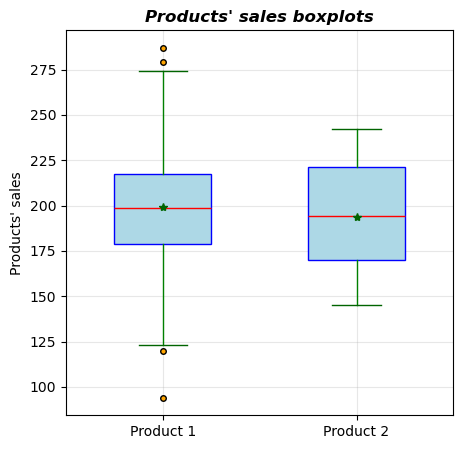

In [37]:
fig, ax = plt.subplots(figsize = (5, 5))

ax.boxplot([product1_sales, product2_sales], patch_artist = True, widths = 0.5,
                medianprops = {'color': 'red', 'linewidth': 1},
                boxprops = {'facecolor': 'lightblue', 'edgecolor': 'blue'},
                whiskerprops = {'color': 'green'},
                capprops = {'color': '#006400'},
                flierprops = {'marker': '.', 'markerfacecolor': 'orange', 'markersize': 8},
                showmeans = True,
                meanprops = {'marker': '*', 'markerfacecolor': 'darkgreen', 'markeredgecolor': 'darkgreen'})
ax.set_xticks([1, 2], ['Product 1', 'Product 2'])
ax.grid(alpha = 0.3)
ax.set_ylabel("Products' sales")
ax.set_title("Products' sales boxplots", fontweight = 'bold', fontsize = 12, fontstyle = 'italic')

plt.show()

In [39]:
print('''
Как видно по ящикам с усами, выбросы у выручки продукта 1 начинаются при значениях выручки выше примерно 275 и ниже примерно 123 значений.
''')


Как видно по ящикам с усами, выбросы у выручки продукта 1 начинаются при значениях выручки выше примерно 275 и ниже примерно 123 значений.



**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

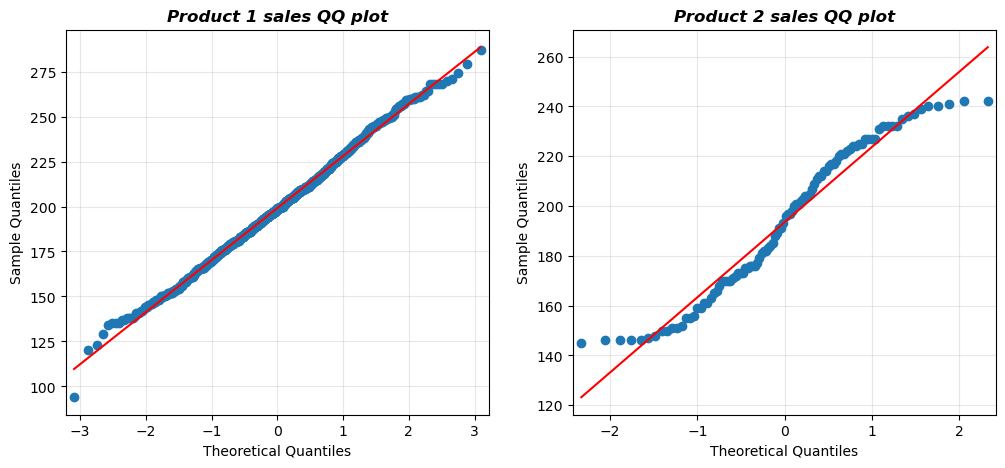

In [42]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

sm.qqplot(product1_sales, line = 'r', ax = ax[0])
ax[0].set_title("Product 1 sales QQ plot", fontweight = 'bold', fontsize = 12, fontstyle = 'italic')
ax[0].grid(alpha = 0.3)

sm.qqplot(product2_sales, line = 'r', ax = ax[1])
ax[1].set_title("Product 2 sales QQ plot", fontweight = 'bold', fontsize = 12, fontstyle = 'italic')
ax[1].grid(alpha = 0.3)

plt.show()

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

In [45]:
print('''
Как видно по QQ plot-ам выручек обоих продуктов, распределение выручки продукта 1 похоже на нормальное распределение, в то время как распределение
выручки продукта 2 - нет. Чтоб распределение выручки продукта 2 было больше похожим на нормальное, нужно добрать значения в районах [120; 140] и
[190; 230], а также убрать переизбыток значений в районах [145; 195] и [235; 260].
''')


Как видно по QQ plot-ам выручек обоих продуктов, распределение выручки продукта 1 похоже на нормальное распределение, в то время как распределение
выручки продукта 2 - нет. Чтоб распределение выручки продукта 2 было больше похожим на нормальное, нужно добрать значения в районах [120; 140] и
[190; 230], а также убрать переизбыток значений в районах [145; 195] и [235; 260].



**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [48]:
product1_sales_std_normal = (product1_sales - product1_sales_mean) / product1_sales_std

Нарисуйте kdeplot нового стандартного распределения

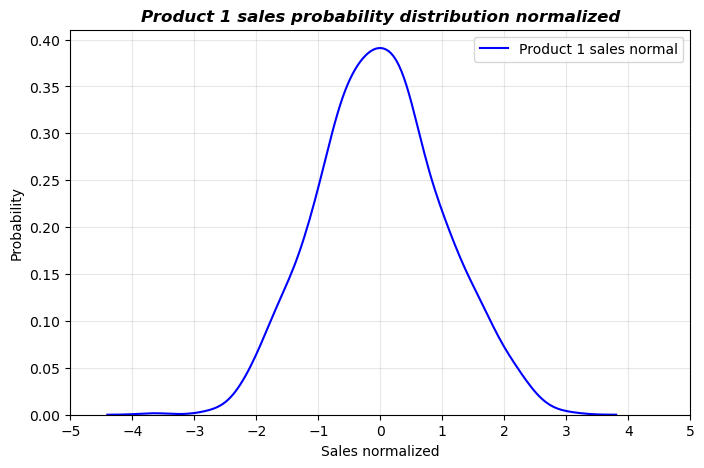

In [51]:
fig, ax = plt.subplots(figsize = (8, 5))

ax = sns.kdeplot(product1_sales_std_normal, label = 'Product 1 sales normal', color = 'blue')

ax.grid(alpha = 0.3)
ax.set_xlabel('Sales normalized')
ax.set_ylabel('Probability')
ax.set_title('Product 1 sales probability distribution normalized', fontweight = 'bold', fontsize = 12, fontstyle = 'italic')
ax.set_xticks(range(-5, 6))
ax.legend(fontsize = 10, loc = 'upper right')

plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [54]:
pr1_sale_01 = np.quantile(product1_sales_std_normal, 0.01, method = 'inverted_cdf')
pr1_sale_01

-2.1557274878463435

Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

In [57]:
print('''
Это говорит о том что, значение 94 стоит на растоянии 3.65 стандартных отклонений меньше среднего значения и стоит довольно-таки далеко от среднего
значения. Это на самом деле, подвтерждает правило, что на расстоянии от 3 стандартных отклонений 99.7% данных, а от 4 - 99.9937%, что является верным,
так как значение 94 является первым значением. Однако, оно никак не относится к тому значению что мы получили ранее, так как предыдущее значение 
показывало порог значений ниже которого лежит 1% общего распределения вероятности, что находится на расстоянии 2.16 стандартных отклонений меньше
среднего значения. Вывод который, можно сделать, что 94 является редким наблюдением, вероятность встречи которого ничтожно мало, так как оно левее
порога ниже которого мы имеем 1% вероятности.
''')


Это говорит о том что, значение 94 стоит на растоянии 3.65 стандартных отклонений меньше среднего значения и стоит довольно-таки далеко от среднего
значения. Это на самом деле, подвтерждает правило, что на расстоянии от 3 стандартных отклонений 99.7% данных, а от 4 - 99.9937%, что является верным,
так как значение 94 является первым значением. Однако, оно никак не относится к тому значению что мы получили ранее, так как предыдущее значение 
показывало порог значений ниже которого лежит 1% общего распределения вероятности, что находится на расстоянии 2.16 стандартных отклонений меньше
среднего значения. Вывод который, можно сделать, что 94 является редким наблюдением, вероятность встречи которого ничтожно мало, так как оно левее
порога ниже которого мы имеем 1% вероятности.



**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [60]:
print(f"Точечная оценка средней выручки продукта 2: {product2_sales_mean:.2f}")

Точечная оценка средней выручки продукта 2: 193.50


Подсчитайте 95% доверительный интервал

In [63]:
CI_ul = norm.ppf(0.975, loc = product2_sales_mean, scale = product2_sales_std)
CI_ll = norm.ppf(0.025, loc = product2_sales_mean, scale = product2_sales_std)

print(f"Доверительный интервал для среднего значения выручки продукта 2: [{CI_ll:.2f}; {CI_ul:.2f}]")

Доверительный интервал для среднего значения выручки продукта 2: [135.21; 251.79]


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [74]:
# H0: Средняя выручка у продукта 1 = 197.5
# H1: Средняя выручка у продукта 1 > 197.5
# Выполняем t-test так как нам неизвестно стандартное отклонение генеральной совокупности.

t_stat = ( product1_sales_mean - 197.5 ) / ( product1_sales_std / np.sqrt(product1_sales.shape[0]) )
dof = len(product1_sales) - 1
p_val = 1 - t.cdf(t_stat, dof)
p_val

0.03939055962434501

Какой это был типа АБ теста?

In [76]:
print('''
Это был односторонний АБ тест, выборка VS значение.
Так как при уровне значимости в 5%, мы получили значение p-value = 0.04, мы можем сделать вывод, что вероятность получить такую выборку очень мала,
что говорит о том что шанс получить такую выборку из-за случайности очень мал. Значит, мы получили статистически значимый результат и отклоняем
нулевую гипотезу. Делаем такой вывод, что у нас достаточно доказательства чтобы утвердить, что средняя выручка у продукта 1 выше чем 197.5.
''')


Это был односторонний АБ тест, выборка VS значение.
Так как при уровне значимости в 5%, мы получили значение p-value = 0.04, мы можем сделать вывод, что вероятность получить такую выборку очень мала,
что говорит о том что шанс получить такую выборку из-за случайности очень мал. Значит, мы получили статистически значимый результат и отклоняем
нулевую гипотезу. Делаем такой вывод, что у нас достаточно доказательства чтобы утвердить, что средняя выручка у продукта 1 выше чем 197.5.



**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [92]:
# H0: Средняя выручка у продукта 1 = средняя выручка у продукта 2
# H1: Средняя выручка у продукта 1 != средняя выручка у продукта 2
# Выполняем t-test так как нам неизвестно стандартное отклонение генеральных совокупностей.

mean_diff = product1_sales_mean - product2_sales_mean
std_err = np.sqrt( (product1_sales_std**2 / len(product1_sales)) + (product2_sales_std**2 / len(product2_sales)) )
dof = len(product1_sales) + len(product2_sales) - 2

t_stat = mean_diff / std_err
p_val = 2 * ( 1 - t.cdf(t_stat, dof) )
p_val

0.07190130082161539

In [94]:
print('''
Это был двухсторонний АБ тест, выборка VS выборка.
Так как при уровне значимости в 5%, мы получили значение p-value = 0.07, мы можем сделать вывод, что вероятность получить такие выборки не очень мала,
что говорит о том что шанс получить такие выборки из-за случайности есть. Значит, мы получили статистически не значимый результат и не можем отклонить
нулевую гипотезу. Делаем такой вывод, что у нас не достаточно доказательства чтобы отклонить нулевую гипотезу и утвердить, что средняя выручка у
продукта 1 не равна средней выруче продукта 2.
''')


Это был двухсторонний АБ тест, выборка VS выборка.
Так как при уровне значимости в 5%, мы получили значение p-value = 0.07, мы можем сделать вывод, что вероятность получить такие выборки не очень мала,
что говорит о том что шанс получить такие выборки из-за случайности есть. Значит, мы получили статистически не значимый результат и не можем отклонить
нулевую гипотезу. Делаем такой вывод, что у нас не достаточно доказательства чтобы отклонить нулевую гипотезу и утвердить, что средняя выручка у
продукта 1 не равна средней выруче продукта 2.

